# Imports

In [4]:
%load_ext autoreload
%autoreload 2
import gc
import os
import sys
import random
import wandb
sys.path.append('../utils')
sys.path.append('../data_utils')
sys.path.append('../models')
sys.path.append('../eval')
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item, ABCdataset, get_vdb_data_loader
import mesh_tools as mt
import model_tools as mtools
import flow_matching_tools as fmt
import get_basic_eval as beval
import fvdb_utils as fu
import model as fvdbModel
import unet as fvdbUnet
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure
import trimesh
from torchviz import make_dot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def load_dataset(data_dir, n_samples=None):
    
    # raise ValueError if the n_samples is not None and Int
    if n_samples is not None and not isinstance(n_samples, int):
        raise ValueError("n_samples must be an integer or None")
    # raise ValueError if the dir is not a directory
    if not os.path.isdir(data_dir):
        raise ValueError(f"The provided path {dir} is not a directory")
    
    if n_samples is not None:
        train_set_names = os.listdir(data_dir)[:n_samples]
    elif n_samples is None:
        train_set_names = os.listdir(data_dir)
        
    random.shuffle(train_set_names)
    print(train_set_names[:5]) # Print first 5 names for debugging 
    
    train_size = int(0.6 * len(train_set_names))
    test_size = int(0.2 * len(train_set_names))
    val_size = len(train_set_names) - train_size - test_size
    train_names = train_set_names[:train_size]
    val_names = train_set_names[train_size:train_size + val_size]
    test_names = train_set_names[train_size + val_size:]

    # train_dataset = ABCdataset(data_dir, train_names)
    # val_dataset = ABCdataset(data_dir, val_names)
    test_dataset = ABCdataset(data_dir, test_names, mode='test')

    print(f'Number of samples in the dataset: {len(train_set_names)}')
    # print(f'Number of samples in the train set: {len(train_dataset)}')
    print(f'Number of samples in the test set: {len(test_dataset)}')
    # print(f'Number of samples in the validation set: {len(val_dataset)}')

    # train_data_loader = get_vdb_data_loader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
    # val_data_loader = get_vdb_data_loader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
    # test_data_loader = get_vdb_data_loader(test_dataset, batch_size=1, shuffle=False, num_workers=0, mode='test')
    return test_dataset

In [6]:
wandb_model_name = '26_rerun_24_SSU_PONQ_DATA_UPSAMPLER_FM_trilinear_Unet_v2'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm'
sdf_nmc_dir = '/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC'
ponq_data_dir = '/data/workspaces/spanwar/dataset/ponq_dataset/gt_Quadrics'
abc_data_dir = '/data/workspaces/spanwar/dataset/abc_dataset'

In [18]:
grid, feat, _ = fvdb.load('/data/workspaces/spanwar/results/ssu/test_predictions/26_rerun_24_SSU_PONQ_DATA_UPSAMPLER_FM_trilinear_Unet_v2/00000020.nvdb')
v, f, _ = grid.marching_cubes(feat)
v = v.jdata.numpy()  
f = f.jdata.numpy()
plot(v, f)
pred_mesh = trimesh.Trimesh(vertices=v, faces=f)
# mesh.show()

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000264…

In [17]:
import h5py

# os.listdir(ponq_data_dir) 00000026
# Example: list all datasets in an HDF5 file and extract '32_sdf' if present
h5_path = os.path.join(ponq_data_dir, '00000061.hdf5')
with h5py.File(h5_path, 'r') as f:
    if '32_sdf' in f:
        sdf_data = f['64_sdf'][:]
        print("Extracted '32_sdf' shape:", sdf_data.shape)
    else:
        print("'32_sdf' not found in file.")

v, f, _, _ = measure.marching_cubes(sdf_data, level=0)
# upload_plot_mesh_to_wandb(v, f, title='input: noise at t=0.0')
plot(v, f)


Extracted '32_sdf' shape: (65, 65, 65)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(32.0, 32.…

Extracted '32_sdf' shape: (65, 65, 65)


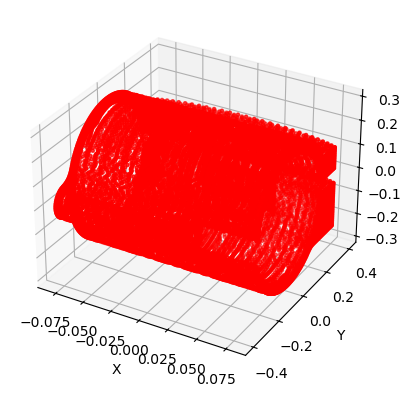

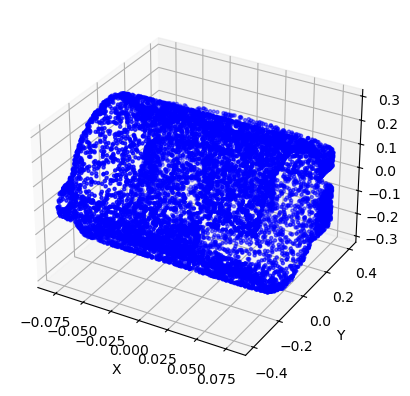

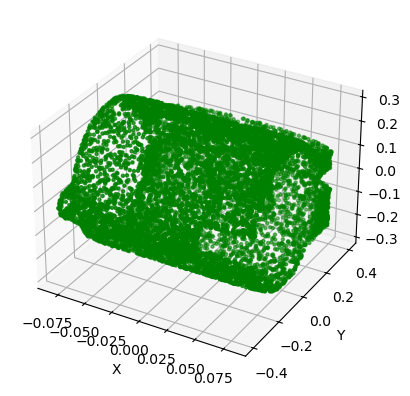

In [19]:
# Read a random .obj file from the abc_data_dir folder
obj_files = [f for f in os.listdir(os.path.join(abc_data_dir, '00000020')) if f.endswith('.obj')]
if not obj_files:
    raise RuntimeError(f"No .obj files found in {abc_data_dir}")
obj_path = os.path.join(abc_data_dir, '00000020', random.choice(obj_files))
# v, f = igl.read_triangle_mesh(obj_path)
#     # normalize object inisde unit cube [-0.5 to 0.5] and multiply by 2 to fit [-1 to 1]
# v = 2*mt.NDCnormalize(v)
def normalize_mesh(v, target_range=1.0):
    # v: (N, 3) array of vertices
    v = np.array(v)
    centroid = v.mean(axis=0)
    v_centered = v - centroid
    max_extent = np.max(np.abs(v_centered))
    v_normalized = v_centered / max_extent * (target_range / 2)
    return v_normalized

trimesh_mesh = trimesh.load(obj_path)
v_abc = trimesh_mesh.vertices
v_abc_n = mt.NDCnormalize(trimesh_mesh.vertices)
h5_path = os.path.join(ponq_data_dir, '00000020.hdf5')

with h5py.File(h5_path, 'r') as f:
    if '32_sdf' in f:
        sdf_data = f['64_sdf'][:]
        print("Extracted '32_sdf' shape:", sdf_data.shape)
    else:
        print("'32_sdf' not found in file.")

v, f, _, _ = measure.marching_cubes(sdf_data, level=0)

# upload_plot_mesh_to_wandb(v, f, title='input: noise at t=0.0')
# plot(v, f)
ponq_mesh = trimesh.Trimesh(vertices=v, faces=f)
v_ponq,_ =  ponq_mesh.sample(10000, return_index=True)
v_ponq_n = mt.NDCnormalize(v_ponq)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# v1 and v2: (N, 3) arrays of vertices
v1 = np.array(v_abc_n)
v2 = np.array(v_ponq_n)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(v1[:, 0], v1[:, 1], v1[:, 2], s=5, c='r', label='Vertices 1')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(v2[:, 0], v2[:, 1], v2[:, 2], s=5, c='b', label='Vertices 2')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

# prediction plot
v_pred,_ =  pred_mesh.sample(10000, return_index=True)
v_pred_n = mt.NDCnormalize(v_pred)
v3 = np.array(v_pred_n)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(v3[:, 0], v3[:, 1], v3[:, 2], s=5, c='g', label='Vertices 3')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

In [27]:
random.seed(42) 
test_data_loader = load_dataset(ponq_data_dir, n_samples=None)

['00006814.hdf5', '00009552.hdf5', '00009473.hdf5', '00005827.hdf5', '00009158.hdf5']


  0%|          | 0/1433 [00:00<?, ?it/s]

100%|██████████| 1433/1433 [00:10<00:00, 134.97it/s]


Number of samples in the dataset: 7168
Number of samples in the test set: 1433


In [60]:
# load save model
model = torch.load(f'../save_models/{wandb_model_name}.pth')
model.eval()

/tmp/ipykernel_2209189/1774082674.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f'../save_models/{wandb_model_name}.pth')


FVDBUNetBase(
  (conv0p1s1): SparseConv3d(12, 32, kernel_size=(5, 5, 5), bias=False)
  (bn0): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1p1s2): SparseConv3d(32, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2), bias=False)
  (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): Sequential(
    (0): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps

In [61]:
def prediction(model, input, output, is_diffusion=True):
    if not is_diffusion:
        input = fmt.positional_encoding(input, 10).to(device)
        pred = model(input, output.grid)
        return pred, None, None
    elif is_diffusion:
        steps = 10
        for i, t in enumerate(torch.linspace(0.0, 1, steps), start=1):
            # print(i,t)
            t = torch.full_like(output.jdata, t).to(device)
            if i==1:
                xt, noise = fmt.transform_input(input, output, t=t, 
                                            scale_factor=2, 
                                            upsampler='trilinear', 
                                            g_noise=False,
                                            # keep_gt=True,
                                            test=True)
                noise_i = noise
            else:
                xt, noise = fmt.transform_input(noise, output, t=t, 
                                            upsampler=None, 
                                            g_noise=False,
                                            test=True)
                
            pred = model(xt)
            noise = noise.jdata + (1 / steps) * pred.jdata
            noise = fvnn.VDBTensor(xt.grid, xt.grid.jagged_like(noise))
        return None, noise, noise_i


In [ ]:
def display_results(idx, model, is_diffusion):

    # idx = random.randint(0, len(test_dataset)-1)
    small_sdf, large_sdf, mask, input, actual = test_data_loader[idx]
    # input = positional_encoding(input, pos_enc_dim).to(device)

    # large grid from small VDBTensor
    small_vdb, large_grid = fu.sdf_to_vdb(small_sdf, 
                                        None, 
                                        mask = mask, 
                                        size=33, mode='test')
    
    pred, noise, noise_i = prediction(model, input, actual, is_diffusion=is_diffusion)
    
    v, f = fu.vdb_marching_cubes(small_vdb)
    # upload_plot_mesh_to_wandb(v, f, title='small SDF')
    plot(v,f)

    if not is_diffusion:
        # make_dot(pred.data.jdata, params=dict(list(model.named_parameters()))).render("model_architecture", format="png")
        v, f = fu.vdb_marching_cubes(pred)
        # upload_plot_mesh_to_wandb(v, f, title='large grid')
        plot(v, f)
    elif is_diffusion:
        # make_dot(noise.data.jdata, params=dict(list(model.named_parameters())))
        v, f = fu.vdb_marching_cubes(noise_i)
        # upload_plot_mesh_to_wandb(v, f, title='input: noise at t=0.0')
        plot(v, f)

        v, f = fu.vdb_marching_cubes(noise)
        # upload_plot_mesh_to_wandb(v, f, title='predition')
        plot(v, f)

    v, f = fu.vdb_marching_cubes(actual)
    # upload_plot_mesh_to_wandb(v, f, title='actual')
    plot(v, f)

In [66]:
def eval_and_display_model(model, idx=13, is_diffusion=True):
    # eval
    # for i in tqdm(range(1, 100)):
    #     _, _, _, input, actual = test_data_loader[i]
    #     l1_list, l2_list, fid_list, f1_list, ss_list = [], [], [], [], []
    #     pred, noise, _ = prediction(model, input, actual, is_diffusion=is_diffusion)
    #     if not is_diffusion:
    #         pred = pred.jdata.cpu().detach().numpy()
    #         actual = actual.jdata.cpu().detach().numpy()
    #         l1, l2, fid, f1, ss = beval.evaluate_1d_metrics(pred, actual, tau=0.005)
    #     elif is_diffusion:
    #         noise = noise.jdata.cpu().detach().numpy()
    #         actual = actual.jdata.cpu().detach().numpy()
    #         l1, l2, fid, f1, ss  = beval.evaluate_1d_metrics(noise, actual, tau=0.005)

    #     l1_list.append(l1)
    #     l2_list.append(l2)
    #     fid_list.append(fid)
    #     f1_list.append(f1)
    #     ss_list.append(ss)
    # print(f"L1: {np.mean(l1_list)}, L2: {np.mean(l2_list)}, FID: {np.mean(fid_list)}, F1: {np.mean(f1_list)}, SS: {np.mean(ss_list)}")
    # display results
    display_results(idx, model, is_diffusion)

In [67]:
eval_and_display_model(model)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, -2.2…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, -2.2…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000183…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, -2.2…

In [55]:
# load save model
model = torch.load(f'../save_models/SSU_PONQ_DATA_UPSAMPLER_Unet.pth')
model.eval()

/tmp/ipykernel_2209189/1684389604.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f'../save_models/SSU_PONQ_DATA_UPSAMPLER_Unet.pth')


FVDBUNetBaseUpsampler(
  (conv0p1s1): SparseConv3d(11, 32, kernel_size=(5, 5, 5), bias=False)
  (bn0): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1p1s2): SparseConv3d(32, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2), bias=False)
  (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): Sequential(
    (0): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNor

In [56]:
eval_and_display_model(model, is_diffusion=False)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, -2.2…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0005592…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, -2.2…